<a href="https://colab.research.google.com/github/celinekm/CN/blob/main/atv1CN_celine_miyajima.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Nome: Celine Kazumi Miyajima RA: 176209**

PREPARAÇÃO

In [ ]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

import imageio.v2 as imageio

def truncar(x, n):

    fator = 10 ** n
    return np.trunc(x * fator) / fator

def erro_absoluto(x, x_aproximado):
    return abs(x - x_aproximado)


def erro_relativo(x, x_aproximado):
    if x == 0:
        return np.nan

    return abs(x - x_aproximado) / abs(x)

def erro_percentual(x, x_aproximado):
    Er = erro_relativo(x, x_aproximado)
    return 100 * Er

**PARTE A - TRUNCAMENTO E ARREDONDAMENTO**

In [ ]:
valores = {
    "x1": 3.14159265,
    "x2": 98.76543,
    "x3": 0.00498765
}

casas_decimais = [0, 1, 2, 3, 4]

resultados = []

for nome, x in valores.items():

    for n in casas_decimais:

        valor_truncado = truncar(x, n)
        valor_arredondado = round(x, n)

        Ea_trunc = erro_absoluto(x, valor_truncado)
        Er_trunc = erro_relativo(x, valor_truncado)
        Ep_trunc = erro_percentual(x, valor_truncado)

        Ea_arred = erro_absoluto(x, valor_arredondado)
        Er_arred = erro_relativo(x, valor_arredondado)
        Ep_arred = erro_percentual(x, valor_arredondado)

        resultados.append({
            "Valor": nome,
            "Valor original": x,
            "n": n,

            "Truncamento": valor_truncado,
            "Ea truncamento": Ea_trunc,
            "Er truncamento": Er_trunc,
            "E% truncamento": Ep_trunc,

            "Arredondamento": valor_arredondado,
            "Ea arredondamento": Ea_arred,
            "Er arredondamento": Er_arred,
            "E% arredondamento": Ep_arred
        })

        tabela_resultados = pd.DataFrame(resultados)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.10f}")

display(tabela_resultados)

,Valor,Valor original,n,Truncamento,Ea truncamento,Er truncamento,E% truncamento,Arredondamento,Ea arredondamento,Er arredondamento,E% arredondamento
0,x1,3.1415926500,0,3.0000000000,0.1415926500,0.0450703404,4.5070340357,3.0000000000,0.1415926500,0.0450703404,4.5070340357
1,x1,3.1415926500,1,3.1000000000,0.0415926500,0.0132393517,1.3239351703,3.1000000000,0.0415926500,0.0132393517,1.3239351703
2,x1,3.1415926500,2,3.1400000000,0.0015926500,0.0005069562,0.0506956241,3.1400000000,0.0015926500,0.0005069562,0.0506956241
3,x1,3.1415926500,3,3.1410000000,0.0005926500,0.0001886464,0.0188646354,3.1420000000,0.0004073500,0.0001296635,0.0129663532
4,x1,3.1415926500,4,3.1415000000,0.0000926500,0.0000294914,0.0029491411,3.1416000000,0.0000073500,0.0000023396,0.0002339578
5,x2,98.7654300000,0,98.0000000000,0.7654300000,0.0077499789,0.7749978915,99.0000000000,0.2345700000,0.0023750213,0.2375021300
6,x2,98.7654300000,1,98.7000000000,0.0654300000,0.0006624788,0.0662478764,98.8000000000,0.0345700000,0.0003500213,0.0350021257
7,x2,98.7654300000,2,98.7600000000,0.0054300000,0.0000549788,0.0054978751,98.7700000000,0.0045700000,0.0000462713,0.0046271251
8,x2,98.7654300000,3,98.7650000000,0.0004300000,0.0000043538,0.0004353750,98.7650000000,0.0004300000,0.0000043538,0.0004353750
9,x2,98.7654300000,4,98.7654000000,0.0000300000,0.0000003038,0.0000303750,98.7654000000,0.0000300000,0.0000003038,0.0000303750


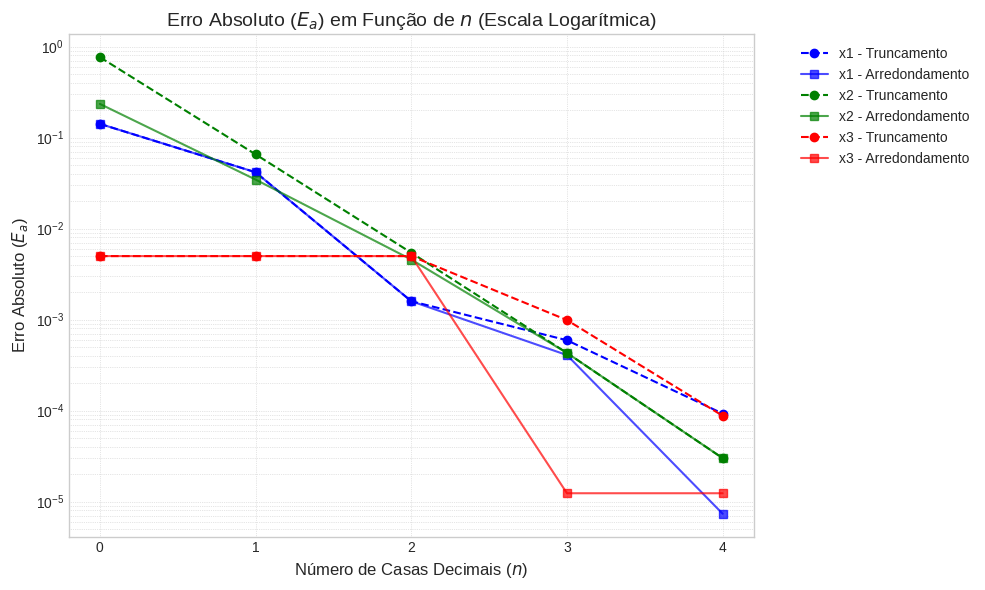

In [ ]:
plt.figure(figsize=(10, 6))

cores = {"x1": "blue", "x2": "green", "x3": "red"}

for nome in valores.keys():
  df_sub = tabela_resultados[tabela_resultados["Valor"] == nome]

  plt.plot(
      df_sub["n"],
      df_sub["Ea truncamento"],
      marker="o",
      linestyle="--",
      color=cores[nome],
      label=f"{nome} - Truncamento",
  )

  plt.plot(
      df_sub["n"],
      df_sub["Ea arredondamento"],
      marker="s",
      linestyle="-",
      color=cores[nome],
      alpha=0.7,
      label=f"{nome} - Arredondamento",
  )

plt.yscale("log")
plt.xlabel("Número de Casas Decimais ($n$)", fontsize=12)
plt.ylabel("Erro Absoluto ($E_a$)", fontsize=12)
plt.title(
    "Erro Absoluto ($E_a$) em Função de $n$ (Escala Logarítmica)", fontsize=14
)
plt.xticks(casas_decimais)
plt.grid(True, which="both", linestyle=":", linewidth=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

plt.show()

Não. Arredondar não garante, em todos os casos possíveis, erro menor ou igual ao truncamento

**PARTE B - MEDIDAS DE PRESSÃO ARTERIAL**

,Série,Média (mmHg),Mínimo (mmHg),Máximo (mmHg),Amplitude (mmHg),Desvio-padrão amostral (mmHg),Erro absoluto da média (mmHg),Erro relativo da média,Erro percentual da média (%)
0,Original,121.120000,119.800,122.400,2.600000,0.833733,0.00000000,0,0
1,Inteiro arredondado,121.100000,120.000,122.000,2.000000,0.875595,0.02000000,0.0001651255,0.01651255
2,Inteiro truncado,120.700000,119.000,122.000,3.000000,0.948683,0.42000000,0.0034676354,0.34676354
3,Arredondado 1 casa,121.120000,119.800,122.400,2.600000,0.833733,0.00000000,0,0


Média de referência = 121.1200000000 mmHg


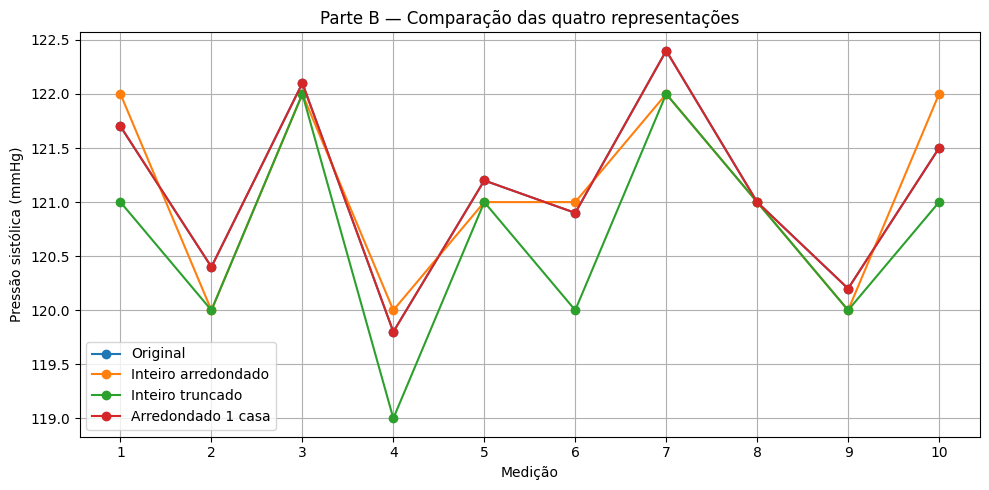

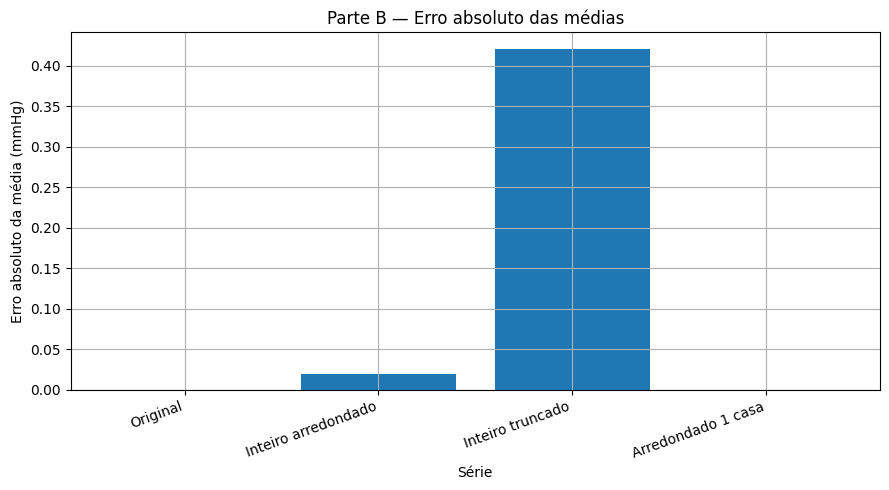

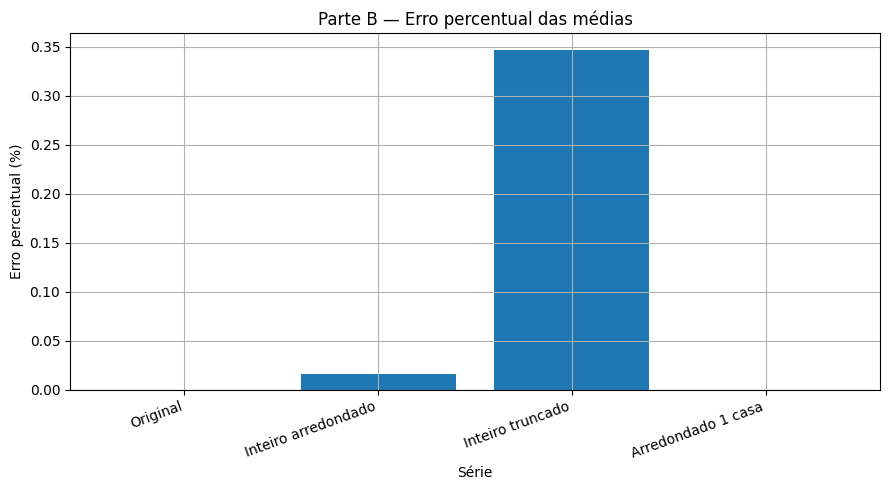

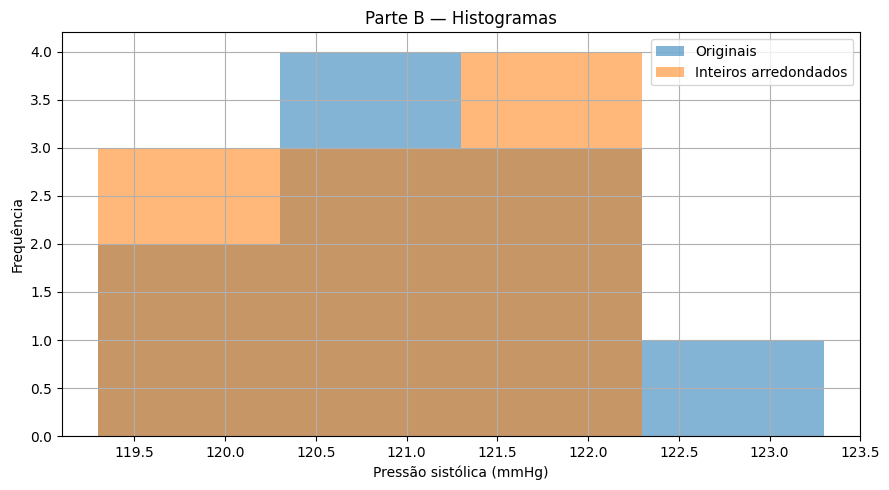